Some weights of BertModel were not initialized from the model checkpoint at /home/maweicheng/ST_Graduation_Project/STEncoder/checkpoints/breast/bert_mlm_epoch_150-train_0.6890093311973491 and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda:0
加载的 vocab 文件路径: ./STEncoder/gene_tokenizer_vocab_nolab.json
✅ 加载了 1938 个配体受体对映射


✅ Loading ViT weights from /home/maweicheng/ST_Graduation_Project/STEncoder/checkpoints/breast/vit_epoch_90_train_0.0068/vit_mim.pt
✅ Loaded pretrained ViT
⚠️ Unexpected keys: 6 parameters ignored (likely from different layer configuration)
✅ Loaded model checkpoint from ./checkpoint/GMS6177601/ST_COMM_epoch200.pth
Found 1 samples for evaluation
process data from: ./database/GSM6177601/GSE203612_GSM6177601.npz
✅ spot_ids 和 graph_spot_ids 顺序一致
✅ spot_ids 和 graph_spot_ids 顺序一致
🔬 Starting model evaluation...
🔬 Starting model evaluation...
✅ 完整边分析CSV保存到 ./evaluation_results/GSM6177601/edge_attention_analysis_full.csv (共111650条边)
✅ 过滤后边分析CSV保存到 ./evaluation_results/GSM6177601/edge_attention_analysis_filtered_attention>5.0_with_LR.csv (共12665条边)
📊 过滤比例: 12665/111650 (11.3%)
✅ 完整边分析CSV保存到 ./evaluation_results/GSM6177601/edge_attention_analysis_full.csv (共111650条边)
✅ 过滤后边分析CSV保存到 ./evaluation_results/GSM6177601/edge_attention_analysis_filtered_attention>5.0_with_LR.csv (共12665条边)
📊 过滤比例: 12665

Some weights of BertModel were not initialized from the model checkpoint at /home/maweicheng/ST_Graduation_Project/STEncoder/checkpoints/breast/bert_mlm_epoch_150-train_0.6890093311973491 and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Attention statistics plot saved to ./evaluation_results/GSM6177601/attention_statistics.png
✅ Evaluation results saved to ./evaluation_results/GSM6177601

🔍 Top-20 Edges with Highest Attention Weights:
Rank   Sample       Src Spot        Tgt Spot        Attention       Edge Attr                
1      B9_S0        GSE203612_GSM61776   GSE203612_GSM61776   40.40534210     mean:103.500             
2      B101_S0      GSE203612_GSM61776   GSE203612_GSM61776   40.40534210     mean:-0.500              
3      B119_S0      GSE203612_GSM61776   GSE203612_GSM61776   40.40534210     mean:295.000             
4      B84_S0       GSE203612_GSM61776   GSE203612_GSM61776   40.37922287     mean:380.500             
5      B27_S0       GSE203612_GSM61776   GSE203612_GSM61776   39.77849579     mean:572.000             
6      B27_S4       GSE203612_GSM61776   GSE203612_GSM61776   39.77849579     mean:693.000             
7      B27_S5       GSE203612_GSM61776   GSE203612_GSM61776   39.77849579     

/home/maweicheng/ST_Graduation_Project/evaluate.py:537: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  print("聚类分布:")


✅ 聚类完成，发现 9 个聚类
聚类分布:
  聚类 0: 168 个spots
  聚类 1: 146 个spots
  聚类 2: 142 个spots
  聚类 3: 132 个spots
  聚类 4: 116 个spots
  聚类 5: 88 个spots
  聚类 6: 85 个spots
  聚类 7: 75 个spots
  聚类 8: 63 个spots
✅ AnnData对象已保存: ./evaluation_results/GSM6177601/clustering_results/fusion_embeddings_clustered.h5ad
✅ 聚类结果已保存: ./evaluation_results/GSM6177601/clustering_results/leiden_clustering_results.csv
=== 生成聚类可视化图像 ===
使用背景图像: STimage-1K4M/breast/image/GSE203612_GSM6177601.png
✅ 聚类可视化已保存: ./evaluation_results/GSM6177601/clustering_results/fusion_embedding_leiden_clusters.png
✅ 聚类可视化已保存: ./evaluation_results/GSM6177601/clustering_results/fusion_embedding_leiden_clusters.png


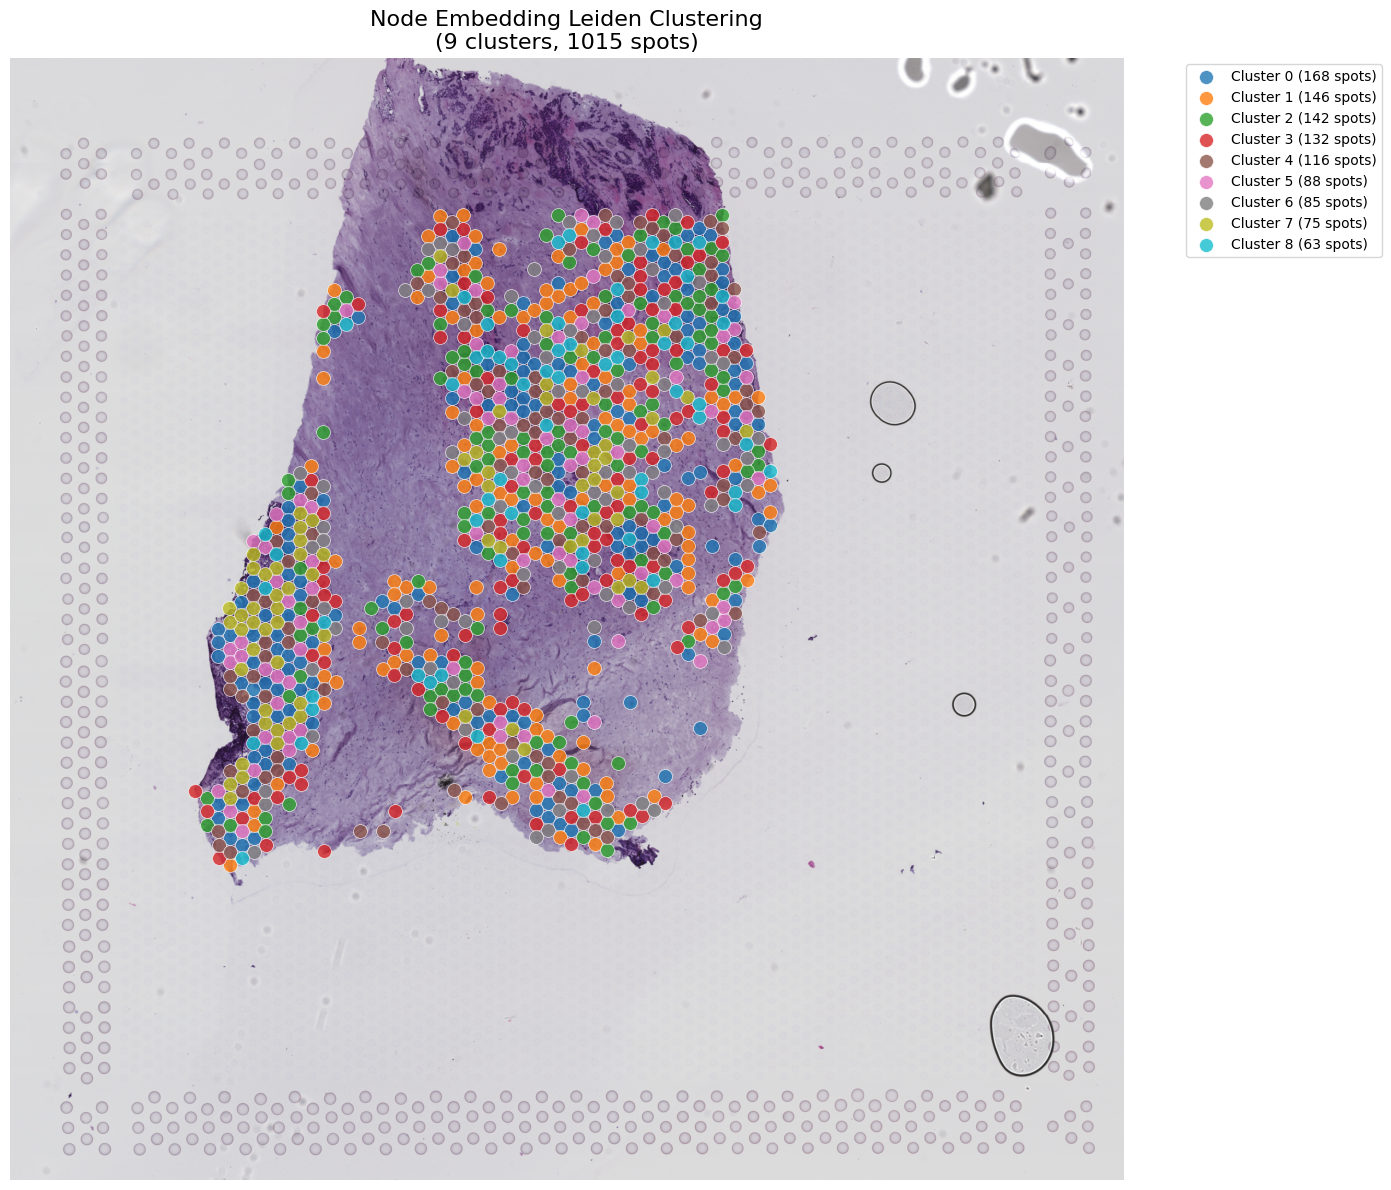

✅ 聚类统计图已保存: ./evaluation_results/GSM6177601/clustering_results/cluster_statistics.png


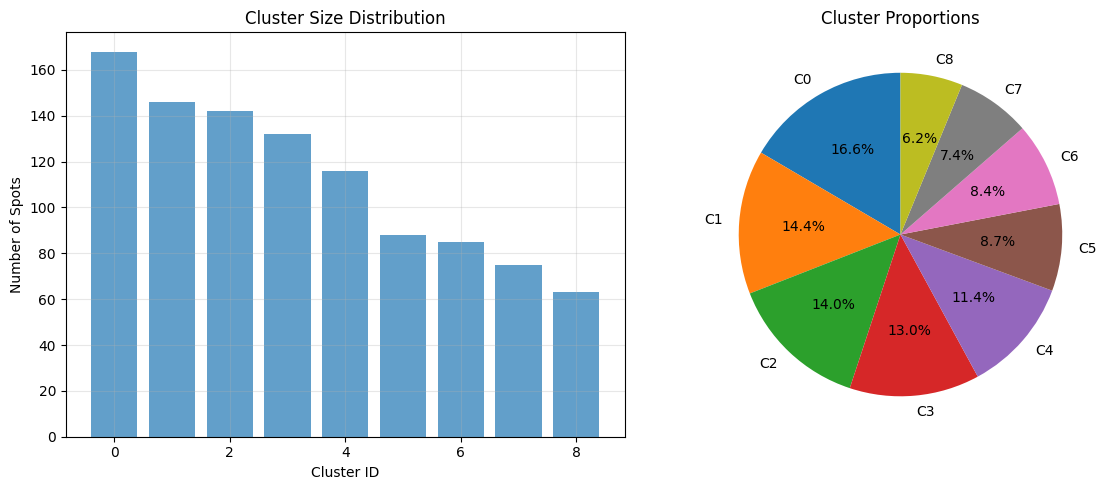

✅ 聚类分析完成！结果保存在 ./evaluation_results/GSM6177601/clustering_results
✅ 聚类分析成功完成！
✅ Evaluation completed!


In [5]:
# 带过滤功能的评估：只保留注意力权重>5且有配体受体对的边
%run evaluate.py \
    --data_dir ./database/GSM6177601 \
    --vocab_file ./STEncoder/gene_tokenizer_vocab_nolab.json \
    --model_checkpoint ./checkpoint/GMS6177601/ST_COMM_epoch200.pth \
    --bert_pretrained_model /home/maweicheng/ST_Graduation_Project/STEncoder/checkpoints/breast/bert_mlm_epoch_150-train_0.6890093311973491 \
    --vit_pretrained_model /home/maweicheng/ST_Graduation_Project/STEncoder/checkpoints/breast/vit_epoch_90_train_0.0068/vit_mim.pt \
    --lr_mapping_file ./ligand_receptor_labeled.csv \
    --output_dir ./evaluation_results/GSM6177601 \
    --device cuda:0 \
    --batch_size 8 \
    --top_k_edges 20 \
    --max_graph_edges 30 \
    --min_node_labels 15 \
    --attention_threshold 5.0 \
    --filter_no_lr \
    --save_detailed \
    --enable_clustering \
    --original_image_path STimage-1K4M/breast/image/GSE203612_GSM6177601.png